<a href="https://colab.research.google.com/github/AyushDev007/AyushDev007/blob/main/Minor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"


(True, 'Tesla T4')

In [ ]:
!pip install mne wfdb torch scipy matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0

In [ ]:
import os

DATA_DIR = "adfecgdb"
os.makedirs(DATA_DIR, exist_ok=True)

base_url = "https://physionet.org/files/adfecgdb/1.0.0"
records = ["r01", "r04", "r07", "r08", "r10"]

for r in records:
    url = f"{base_url}/{r}.edf"
    out_path = f"{DATA_DIR}/{r}.edf"
    if not os.path.exists(out_path):
        print("Downloading", url)
        !wget -q -O {out_path} {url}
    else:
        print("Already exists:", out_path)

print("Files in adfecgdb:", os.listdir(DATA_DIR))


Files in adfecgdb: ['r10.edf', 'r07.edf', 'r08.edf', 'r01.edf', 'r04.edf']


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

import mne  # for reading EDF files
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = "adfecgdb"  # folder where r01.edf, r04.edf, ... are stored
RECORD_FILES = ["r01.edf", "r04.edf", "r07.edf", "r08.edf", "r10.edf"]

FS = 1000          # Sampling frequency (Hz) for ADFECGDB
WINDOW_SEC = 2.0   # length of each window (sec)
STRIDE_SEC = 0.5   # stride between windows (sec)

BATCH_SIZE = 32
NUM_EPOCHS = 15    # keep smaller in Colab first; increase later if you like
LEARNING_RATE = 1e-3
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
USE_GPU = torch.cuda.is_available()


# -----------------------------
# FILTERS
# -----------------------------
def bandpass_filter(x, fs, low=0.5, high=45, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, x)


def notch_filter_50hz(x, fs, freq=50.0, q=30.0):
    b, a = iirnotch(w0=freq, Q=q, fs=fs)
    return filtfilt(b, a, x)


# -----------------------------
# LOAD ALL EDF FILES LOCALLY
# -----------------------------
def load_adfecgdb_local():
    """
    Reads all EDF records in RECORD_FILES from DATA_DIR using mne.

    Returns:
        abd_ecg  : (N_total, 4)  -> 4 abdominal channels
        fetal_ref: (N_total,)    -> direct fetal scalp ECG
    """
    abd_list = []
    fetal_list = []

    for fname in RECORD_FILES:
        path = os.path.join(DATA_DIR, fname)
        print(f"Loading EDF file: {path}")

        if not os.path.exists(path):
            raise FileNotFoundError(f"EDF file not found: {path}")

        # preload=True loads the whole signal into memory
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)

        # data: (n_channels, n_samples) → transpose to (n_samples, n_channels)
        data = raw.get_data().T
        ch_names = raw.ch_names
        print("  Channels:", ch_names)
        print("  Data shape:", data.shape)

        if data.shape[1] < 5:
            raise ValueError(
                f"Expected at least 5 channels in {fname}, found {data.shape[1]}"
            )

        # Channel order:
        # ['Direct_1', 'Abdomen_1', 'Abdomen_2', 'Abdomen_3', 'Abdomen_4']
        # fetal scalp = Direct_1 = channel 0
        # abdomen = channels 1..4
        fetal = data[:, 0]      # Direct fetal ECG
        abd = data[:, 1:5]      # Abdomen_1..Abdomen_4  → shape (N, 4)

        abd_list.append(abd)
        fetal_list.append(fetal)

    abd_ecg = np.concatenate(abd_list, axis=0)        # (N_total, 4)
    fetal_ref = np.concatenate(fetal_list, axis=0)    # (N_total,)

    print("Total samples across all records:", abd_ecg.shape[0])
    return abd_ecg, fetal_ref


# -----------------------------
# WINDOWING
# -----------------------------
def create_windows(abd_ecg, fetal_ref, fs, window_sec, stride_sec):
    """
    abd_ecg : (N, C)
    fetal_ref : (N,)
    Returns:
        X: (num_windows, C, L)
        y: (num_windows, 1, L)
    """
    N, C = abd_ecg.shape
    L = int(window_sec * fs)
    step = int(stride_sec * fs)

    X_list = []
    y_list = []

    for start in range(0, N - L, step):
        end = start + L
        abd_win = abd_ecg[start:end, :]          # (L, C)
        fetal_win = fetal_ref[start:end]         # (L,)

        # per-window normalization
        abd_win_norm = abd_win.copy()
        for c in range(C):
            m = abd_win_norm[:, c].mean()
            s = abd_win_norm[:, c].std() + 1e-8
            abd_win_norm[:, c] = (abd_win_norm[:, c] - m) / s

        fetal_win_norm = fetal_win.copy()
        m_f = fetal_win_norm.mean()
        s_f = fetal_win_norm.std() + 1e-8
        fetal_win_norm = (fetal_win_norm - m_f) / s_f

        X_list.append(abd_win_norm.T)           # (C, L)
        y_list.append(fetal_win_norm[None, :])  # (1, L)

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.stack(y_list, axis=0).astype(np.float32)
    return X, y


# -----------------------------
# DATASET
# -----------------------------
class FetalECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# -----------------------------
# MODEL
# -----------------------------
class FetalECGSeparator(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=15, padding=7)  # 1 output channel = fetal ECG
        )

    def forward(self, x):
        # x: (B, C, L)
        return self.net(x)  # (B, 1, L)


# -----------------------------
# TRAINING
# -----------------------------
def train_model(model, train_loader, val_loader, num_epochs, lr, device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    best_val = float('inf')

    for epoch in range(num_epochs):
        # --- train ---
        model.train()
        running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            yp = model(Xb)
            loss = criterion(yp, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * Xb.size(0)

        train_loss = running / len(train_loader.dataset)

        # --- validate ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                yp = model(Xb)
                loss = criterion(yp, yb)
                val_loss += loss.item() * Xb.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train: {train_loss:.6f}  Val: {val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_fetal_separator_adfecgdb.pth")

    print("Best val loss:", best_val)


# -----------------------------
# VISUALIZATION 1:
# Abdominal + True Fetal + Predicted Fetal (triple panel)
# -----------------------------
def eval_and_plot(model, test_loader, device, fs, num_windows=3, save_dir="figures"):
    os.makedirs(save_dir, exist_ok=True)

    model.to(device)
    model.eval()
    plotted = 0

    with torch.no_grad():
        for batch_idx, (Xb, yb) in enumerate(test_loader):
            Xb, yb = Xb.to(device), yb.to(device)
            yp = model(Xb)

            Xb = Xb.cpu().numpy()
            yb = yb.cpu().numpy()
            yp = yp.cpu().numpy()

            B, C, L = Xb.shape
            t = np.arange(L) / fs

            for i in range(B):
                if plotted >= num_windows:
                    return

                plt.figure(figsize=(10, 7))

                # 1) Abdominal ECG (mixture)
                plt.subplot(3, 1, 1)
                plt.plot(t, Xb[i, 0, :], linewidth=0.8)
                plt.title("Abdominal ECG (Channel 1, normalized)")
                plt.ylabel("Amplitude")
                plt.xlabel("Time (s)")

                # 2) True fetal ECG
                plt.subplot(3, 1, 2)
                plt.plot(t, yb[i, 0, :], linewidth=0.8)
                plt.title("True Fetal ECG (Direct scalp, normalized)")
                plt.ylabel("Amplitude")
                plt.xlabel("Time (s)")

                # 3) Predicted fetal ECG
                plt.subplot(3, 1, 3)
                plt.plot(t, yp[i, 0, :], linewidth=0.8)
                plt.title("Predicted Fetal ECG (Model output, normalized)")
                plt.ylabel("Amplitude")
                plt.xlabel("Time (s)")

                plt.tight_layout()

                # Save high-res PNG + vector PDF
                fig_path_png = os.path.join(save_dir, f"triple_window_{plotted+1}.png")
                fig_path_pdf = os.path.join(save_dir, f"triple_window_{plotted+1}.pdf")
                plt.savefig(fig_path_png, dpi=400)
                plt.savefig(fig_path_pdf)
                print("Saved:", fig_path_png)
                print("Saved:", fig_path_pdf)

                plt.close()
                plotted += 1


# -----------------------------
# VISUALIZATION 2:
# Overlay True vs Predicted Fetal ECG (full window)
# -----------------------------
def plot_overlay_true_vs_pred(model, test_loader, device, fs, save_dir="figures"):
    os.makedirs(save_dir, exist_ok=True)

    model.to(device)
    model.eval()

    with torch.no_grad():
        # take first batch only
        Xb, yb = next(iter(test_loader))
        Xb, yb = Xb.to(device), yb.to(device)
        yp = model(Xb)

        yb = yb.cpu().numpy()
        yp = yp.cpu().numpy()

        # take first sample from batch
        true_fetal = yb[0, 0, :]
        pred_fetal = yp[0, 0, :]
        t = np.arange(true_fetal.shape[0]) / fs

        plt.figure(figsize=(10, 4))
        plt.plot(t, true_fetal, label="True Fetal ECG", linewidth=1.0)
        plt.plot(t, pred_fetal, label="Predicted Fetal ECG", linewidth=1.0, alpha=0.7)
        plt.title("True vs Predicted Fetal ECG (normalized)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.tight_layout()

        png_path = os.path.join(save_dir, "overlay_true_vs_pred.png")
        pdf_path = os.path.join(save_dir, "overlay_true_vs_pred.pdf")
        plt.savefig(png_path, dpi=400)
        plt.savefig(pdf_path)
        print("Saved:", png_path)
        print("Saved:", pdf_path)

        plt.close()


# -----------------------------
# VISUALIZATION 3:
# Zoomed-in QRS overlay (beats clearly visible)
# -----------------------------
def plot_zoomed_qrs(model, test_loader, device, fs, zoom_sec=0.6, save_dir="figures"):
    os.makedirs(save_dir, exist_ok=True)

    model.to(device)
    model.eval()

    with torch.no_grad():
        Xb, yb = next(iter(test_loader))
        Xb, yb = Xb.to(device), yb.to(device)
        yp = model(Xb)

        yb = yb.cpu().numpy()
        yp = yp.cpu().numpy()

        true_fetal = yb[0, 0, :]
        pred_fetal = yp[0, 0, :]

        L = true_fetal.shape[0]
        zoom_samples = int(zoom_sec * fs)

        # choose a region somewhere in the middle
        start = L // 4
        end = start + zoom_samples
        if end > L:
            end = L
            start = end - zoom_samples

        t = np.arange(L) / fs
        t_zoom = t[start:end]

        plt.figure(figsize=(8, 3))
        plt.plot(t_zoom, true_fetal[start:end], label="True Fetal ECG", linewidth=1.0)
        plt.plot(t_zoom, pred_fetal[start:end], label="Predicted Fetal ECG",
                 linewidth=1.0, alpha=0.7)
        plt.title(f"Zoomed Fetal ECG (~{zoom_sec} s segment)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.tight_layout()

        png_path = os.path.join(save_dir, "zoomed_qrs_overlay.png")
        pdf_path = os.path.join(save_dir, "zoomed_qrs_overlay.pdf")
        plt.savefig(png_path, dpi=400)
        plt.savefig(pdf_path)
        print("Saved:", png_path)
        print("Saved:", pdf_path)

        plt.close()


# -----------------------------
# MAIN LOGIC (for notebook)
# -----------------------------
def main():
    # 1) Load & concatenate all ADFECGDB records
    abd_ecg, fetal_ref = load_adfecgdb_local()    # (N, 4), (N,)

    # 2) Filter each channel + fetal reference
    N, C = abd_ecg.shape
    for c in range(C):
        abd_ecg[:, c] = bandpass_filter(abd_ecg[:, c], FS, 0.5, 45)
        abd_ecg[:, c] = notch_filter_50hz(abd_ecg[:, c], FS)

    fetal_ref_filt = bandpass_filter(fetal_ref, FS, 0.5, 45)
    fetal_ref_filt = notch_filter_50hz(fetal_ref_filt, FS)

    # 3) Windowing
    X, y = create_windows(abd_ecg, fetal_ref_filt, FS, WINDOW_SEC, STRIDE_SEC)
    print("Windowed shapes:", X.shape, y.shape)

    dataset = FetalECGDataset(X, y)

    # 4) Train/Val/Test split
    num_samples = len(dataset)
    n_test = int(TEST_SPLIT * num_samples)
    n_val = int(VAL_SPLIT * num_samples)
    n_train = num_samples - n_test - n_val

    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

    # 5) Model
    in_channels = X.shape[1]  # should be 4
    model = FetalECGSeparator(in_channels=in_channels)

    device = torch.device("cuda" if USE_GPU else "cpu")
    print("Using device:", device)

    # 6) Train
    train_model(model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, device)

    # 7) Load best & create high-quality figures
    model.load_state_dict(torch.load("best_fetal_separator_adfecgdb.pth",
                                     map_location=device))

    # Multi-panel (abdominal + true fetal + predicted fetal)
    eval_and_plot(model, test_loader, device, FS,
                  num_windows=3, save_dir="figures")

    # Overlay full-window true vs predicted fetal ECG
    plot_overlay_true_vs_pred(model, test_loader, device, FS,
                              save_dir="figures")

    # Zoomed QRS overlay
    plot_zoomed_qrs(model, test_loader, device, FS,
                    zoom_sec=0.6, save_dir="figures")

# call main() in notebook
main()


Loading EDF file: adfecgdb/r01.edf
  Channels: ['Direct_1', 'Abdomen_1', 'Abdomen_2', 'Abdomen_3', 'Abdomen_4']
  Data shape: (300000, 5)
Loading EDF file: adfecgdb/r04.edf
  Channels: ['Direct_1', 'Abdomen_1', 'Abdomen_2', 'Abdomen_3', 'Abdomen_4']
  Data shape: (300000, 5)
Loading EDF file: adfecgdb/r07.edf
  Channels: ['Direct_1', 'Abdomen_1', 'Abdomen_2', 'Abdomen_3', 'Abdomen_4']
  Data shape: (300000, 5)
Loading EDF file: adfecgdb/r08.edf
  Channels: ['Direct_1', 'Abdomen_1', 'Abdomen_2', 'Abdomen_3', 'Abdomen_4']
  Data shape: (300000, 5)
Loading EDF file: adfecgdb/r10.edf
  Channels: ['Direct_1', 'Abdomen_1', 'Abdomen_2', 'Abdomen_3', 'Abdomen_4']
  Data shape: (300000, 5)
Total samples across all records: 1500000
Windowed shapes: (2996, 4, 2000) (2996, 1, 2000)
Using device: cuda
Epoch [1/15] Train: 0.752960  Val: 0.692112
Epoch [2/15] Train: 0.688939  Val: 0.666034
Epoch [3/15] Train: 0.659252  Val: 0.646643
Epoch [4/15] Train: 0.646331  Val: 0.634078
Epoch [5/15] Train: 0.63

### Generated Figures

Displaying overlay_true_vs_pred.png:


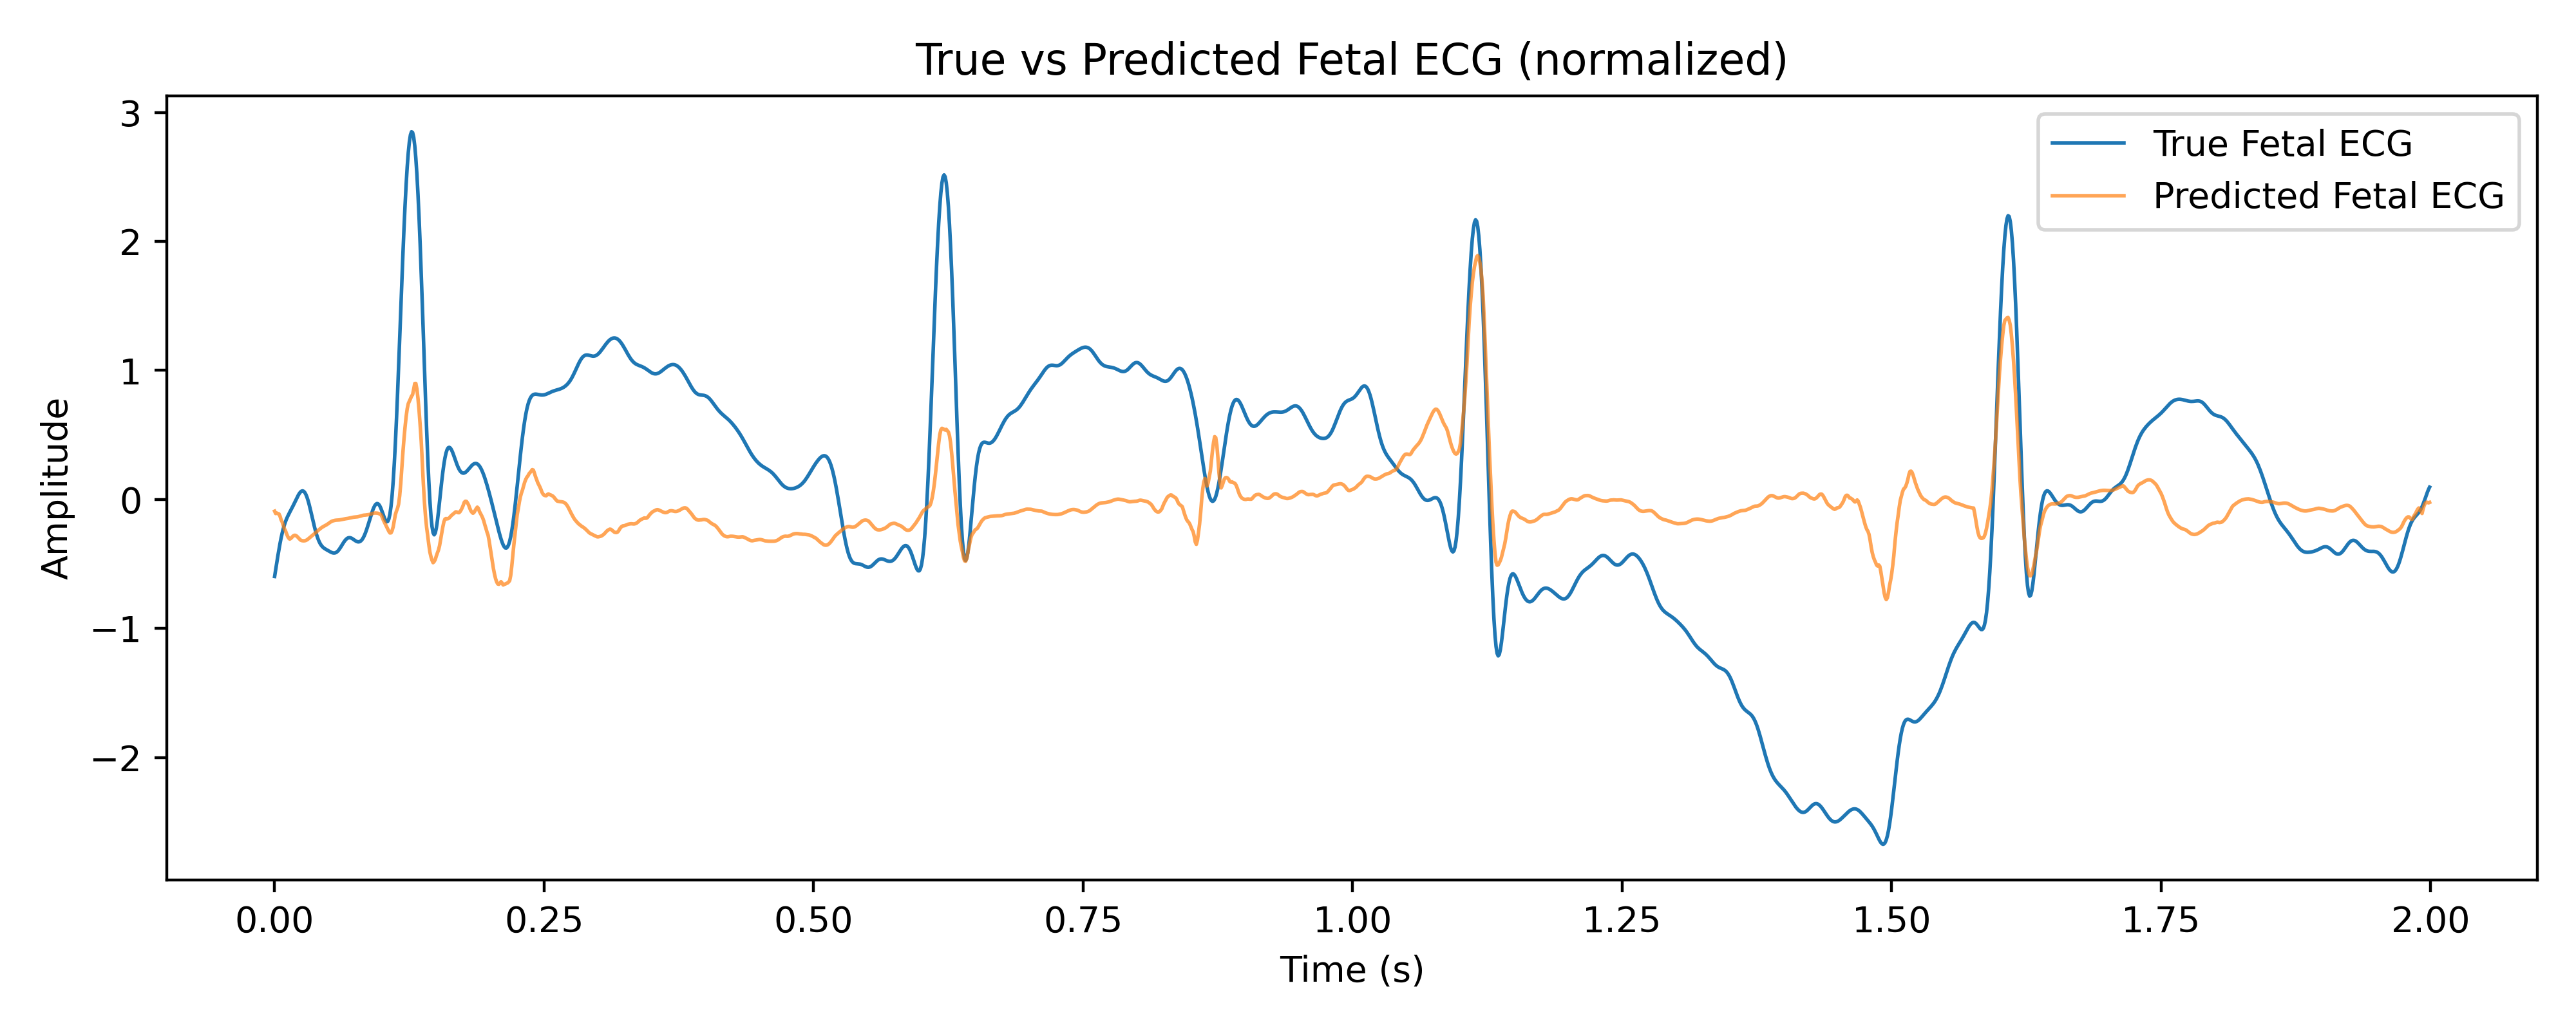

Displaying triple_window_1.png:


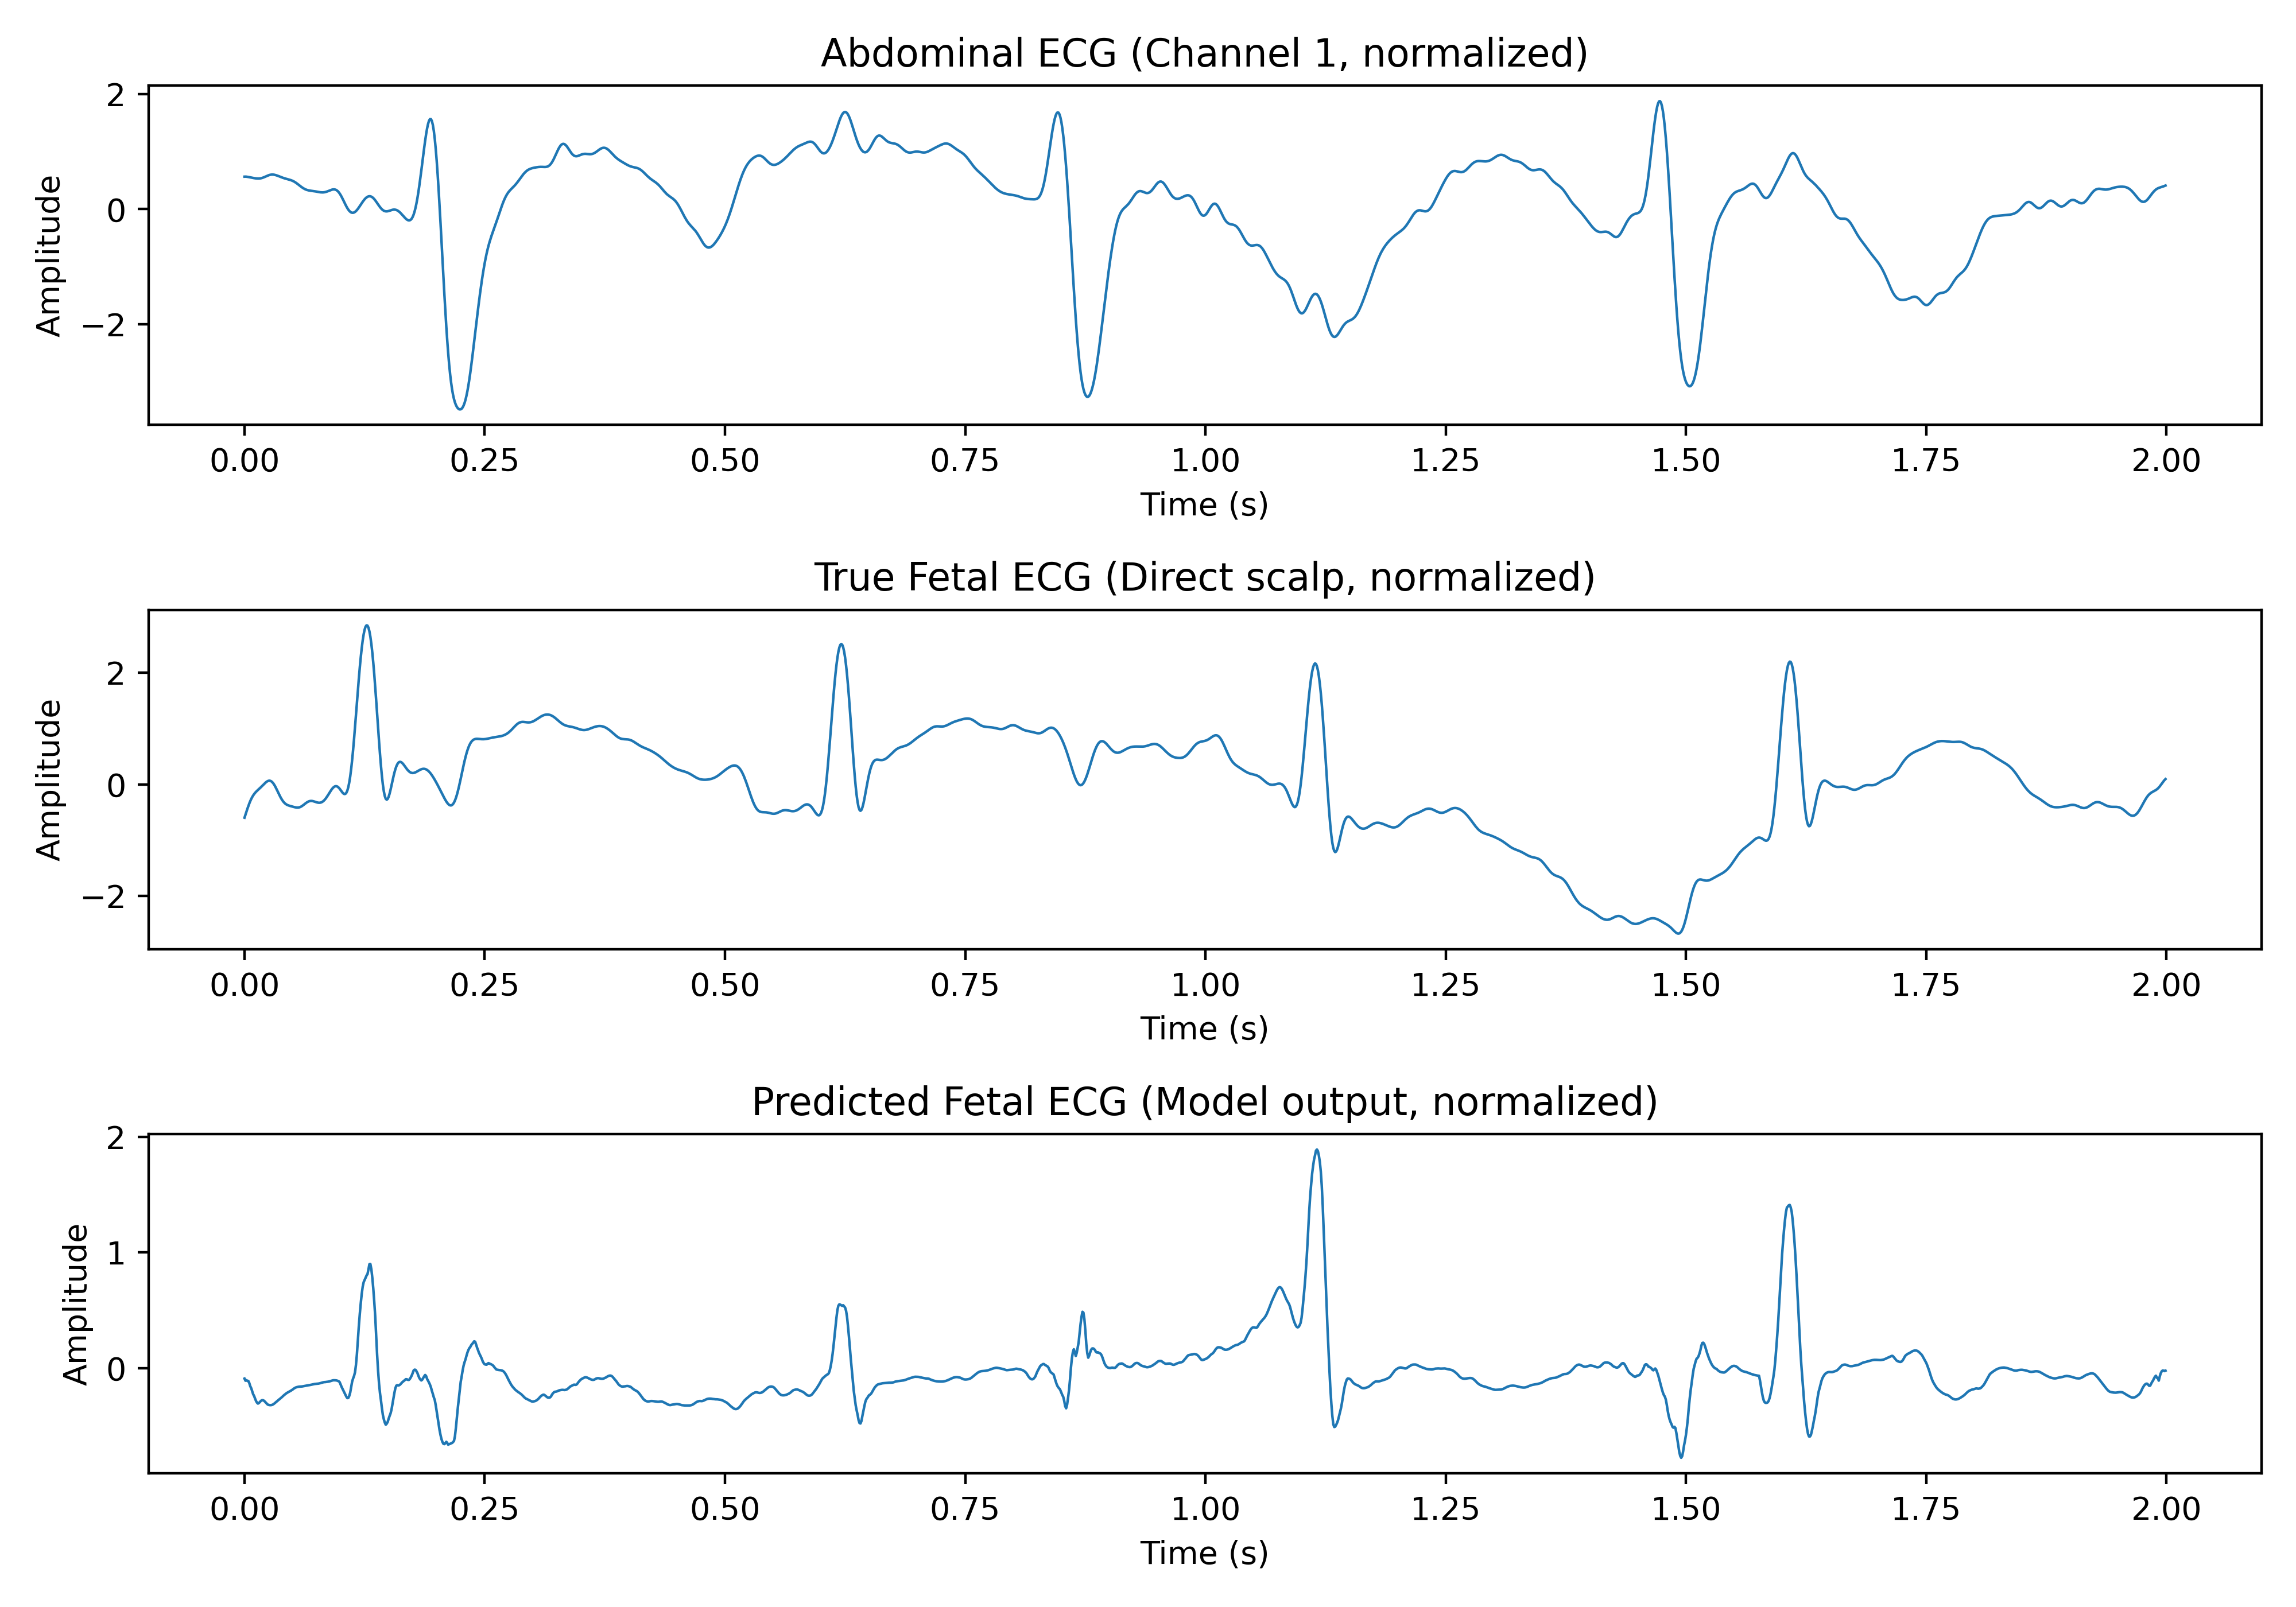

Displaying triple_window_2.png:


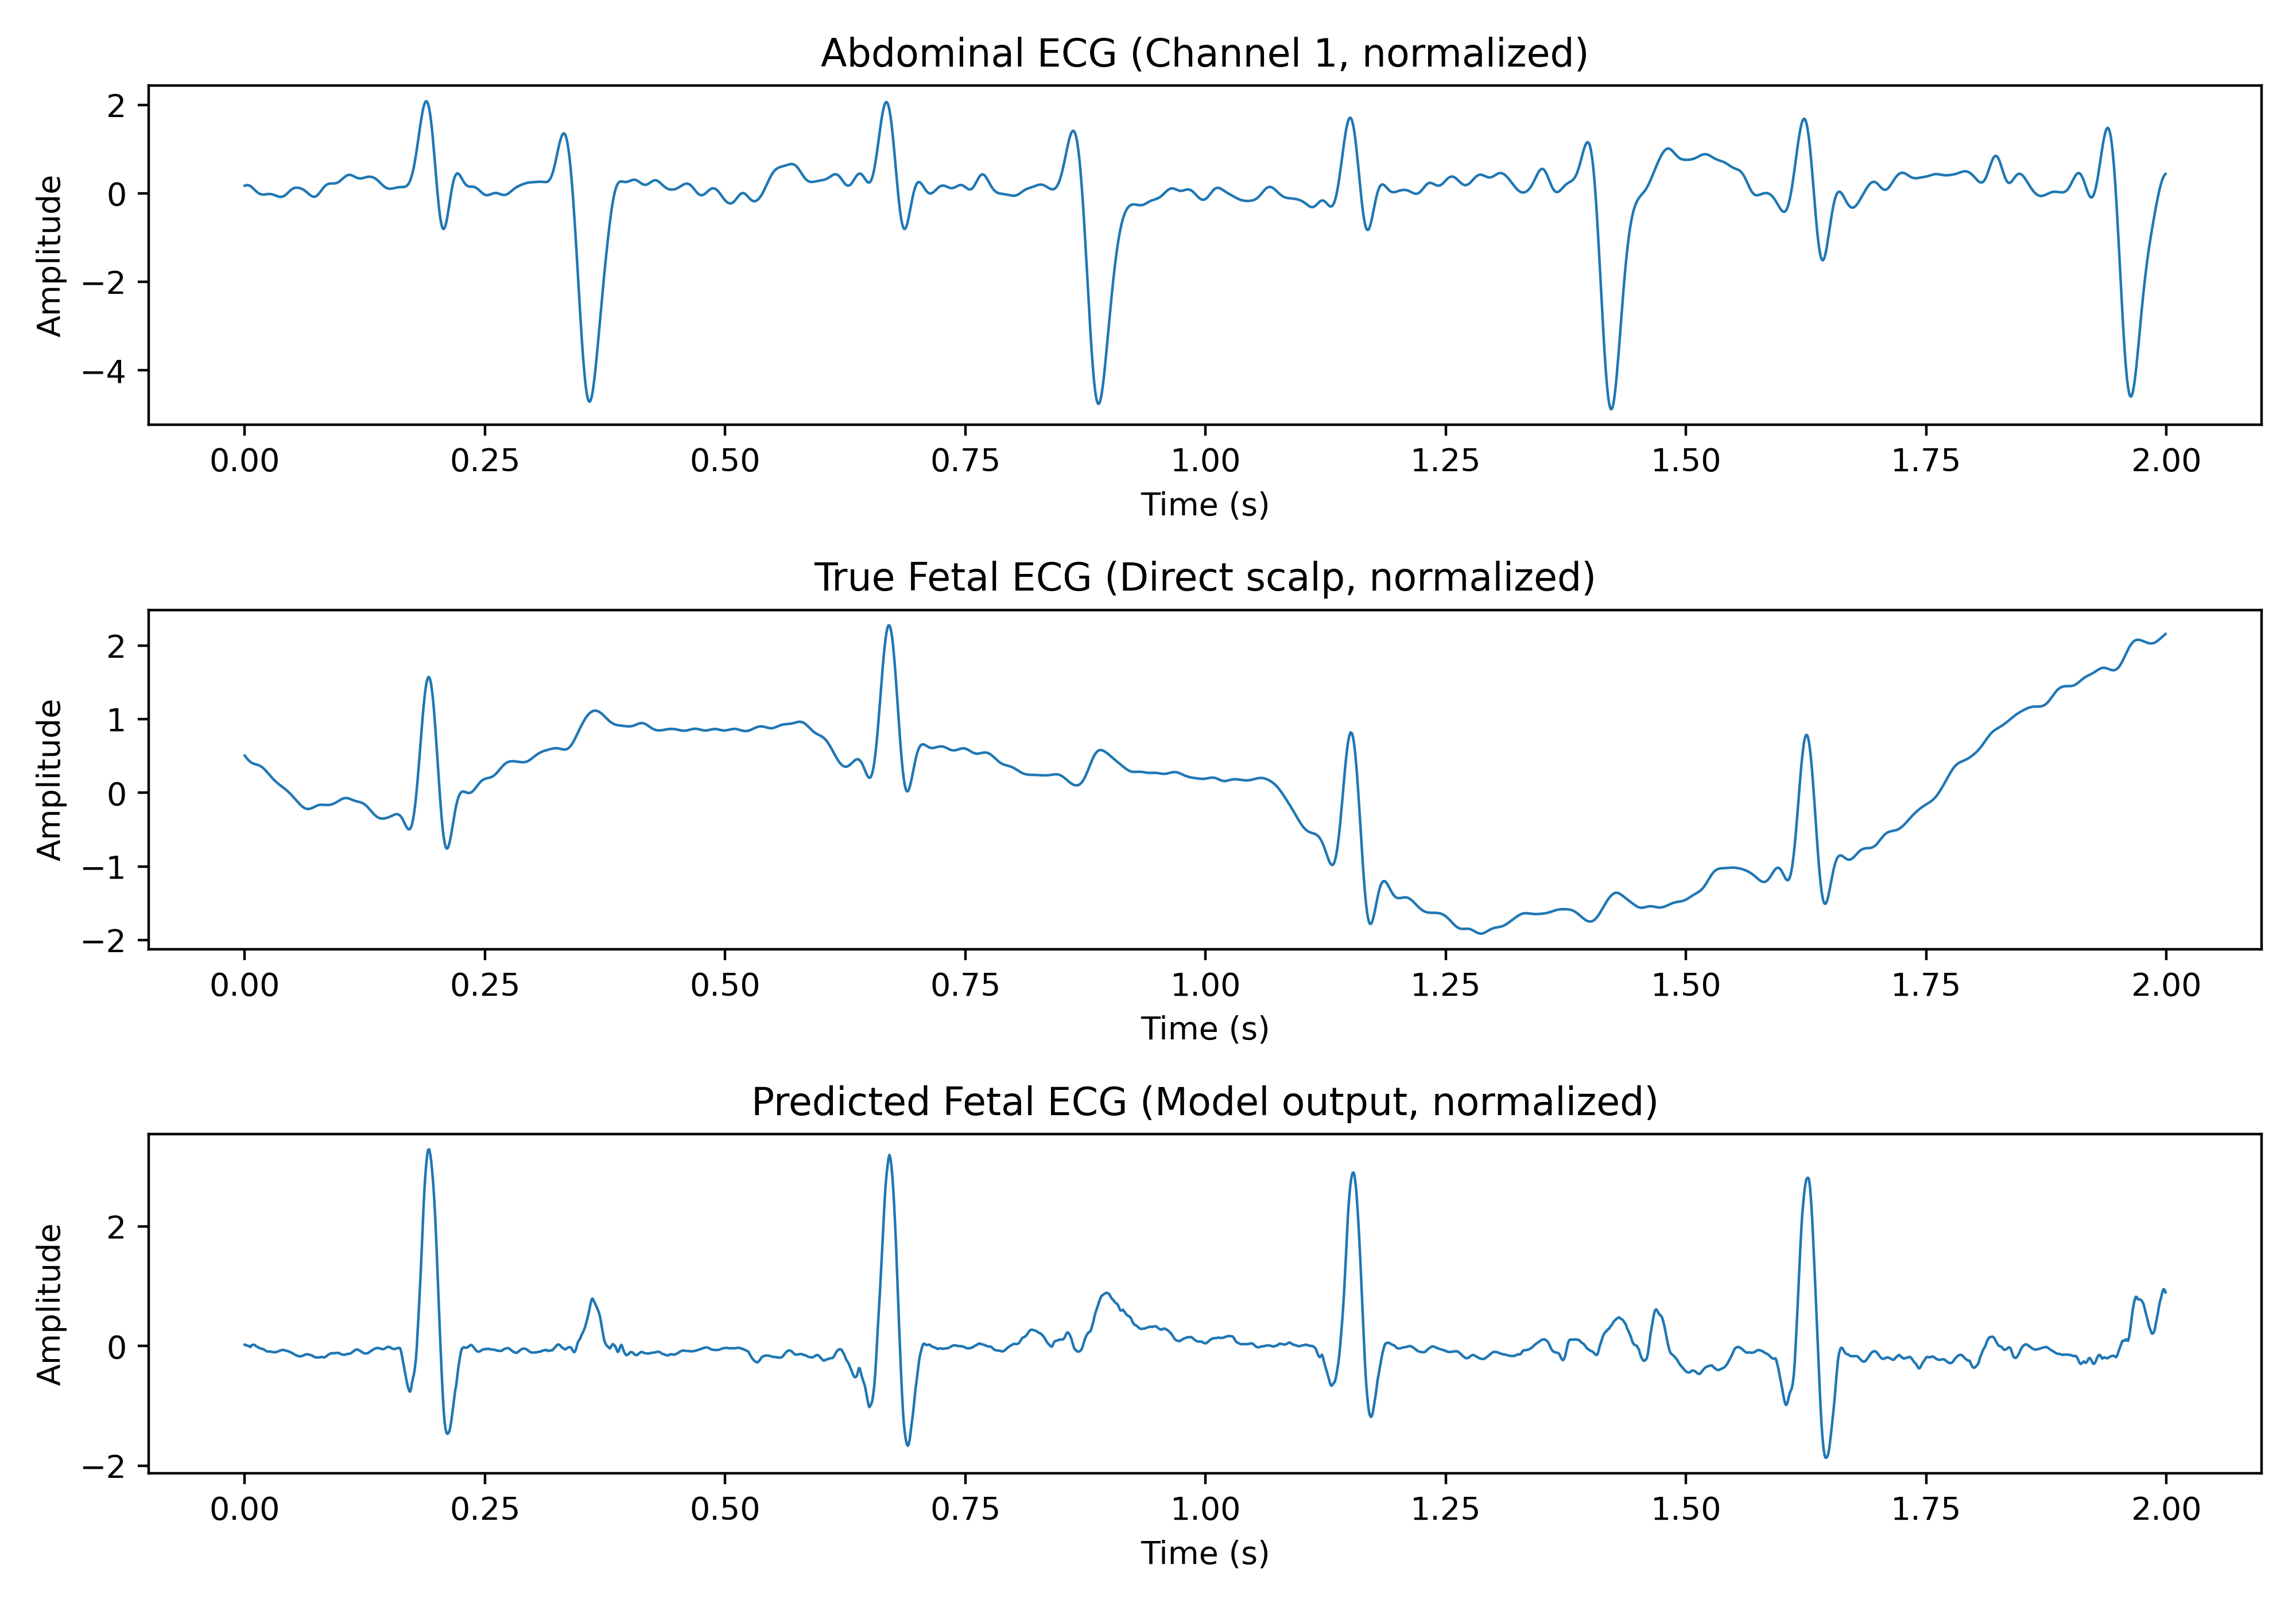

Displaying triple_window_3.png:


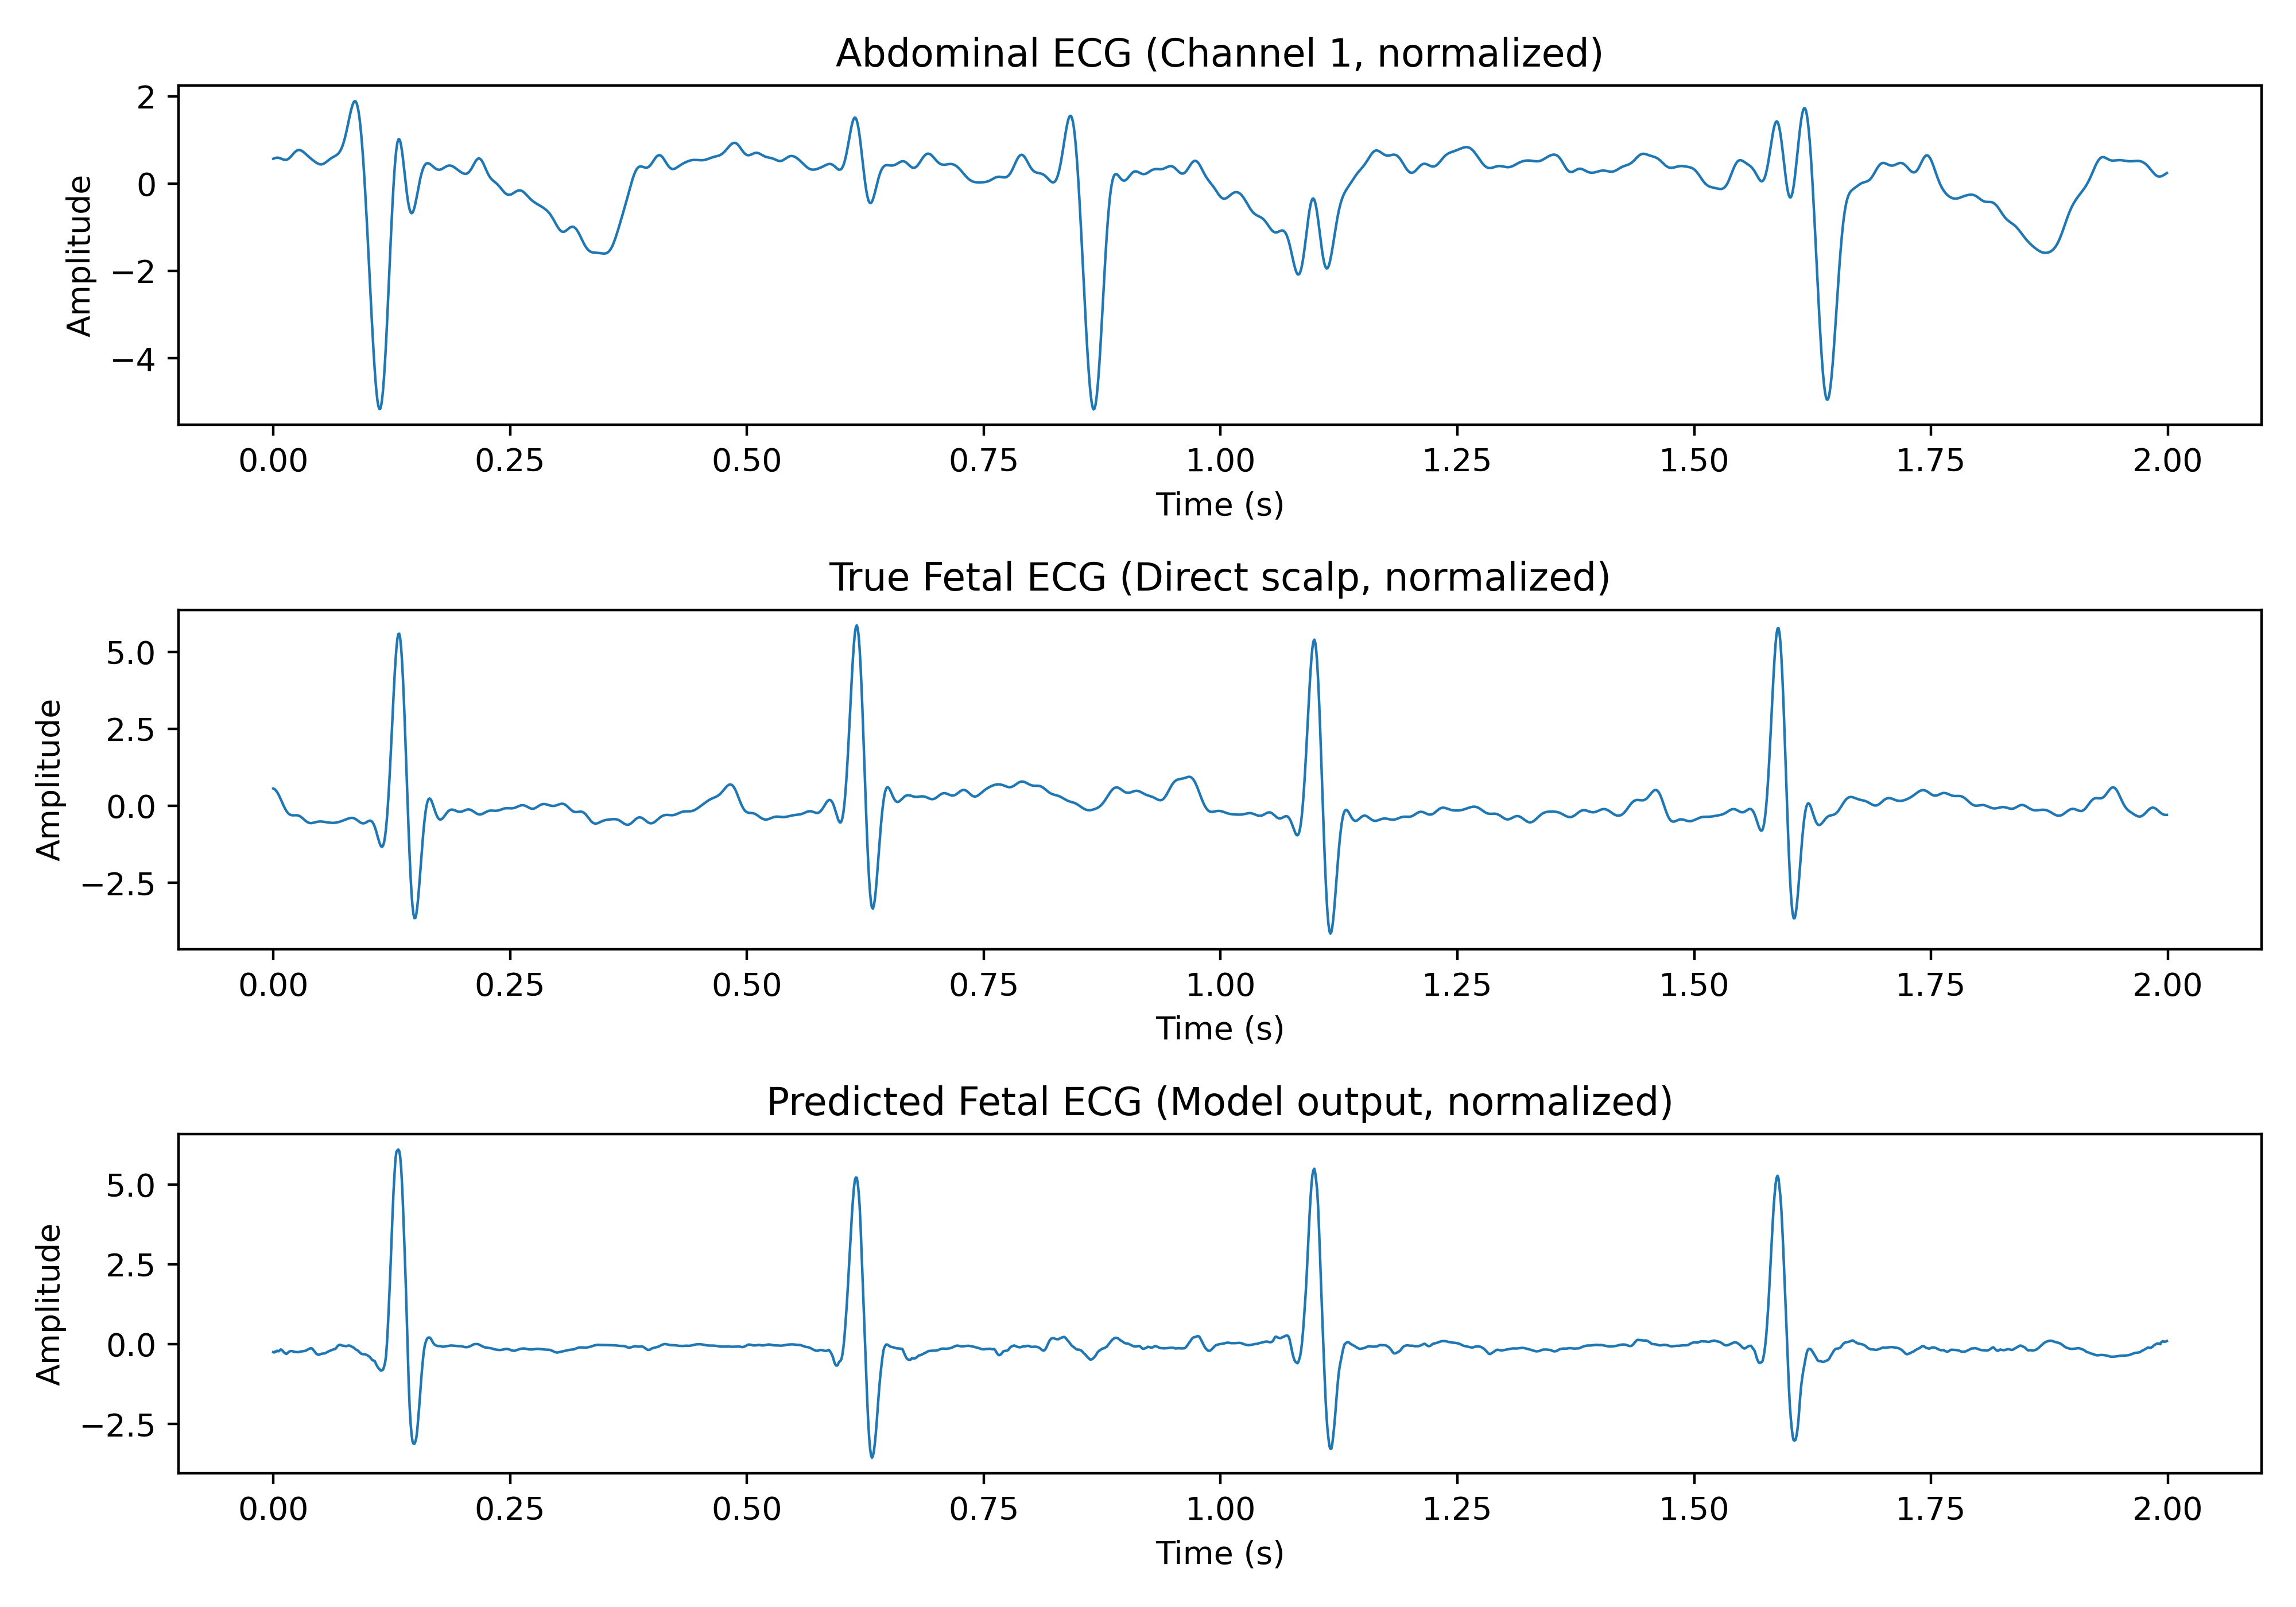

Displaying zoomed_qrs_overlay.png:


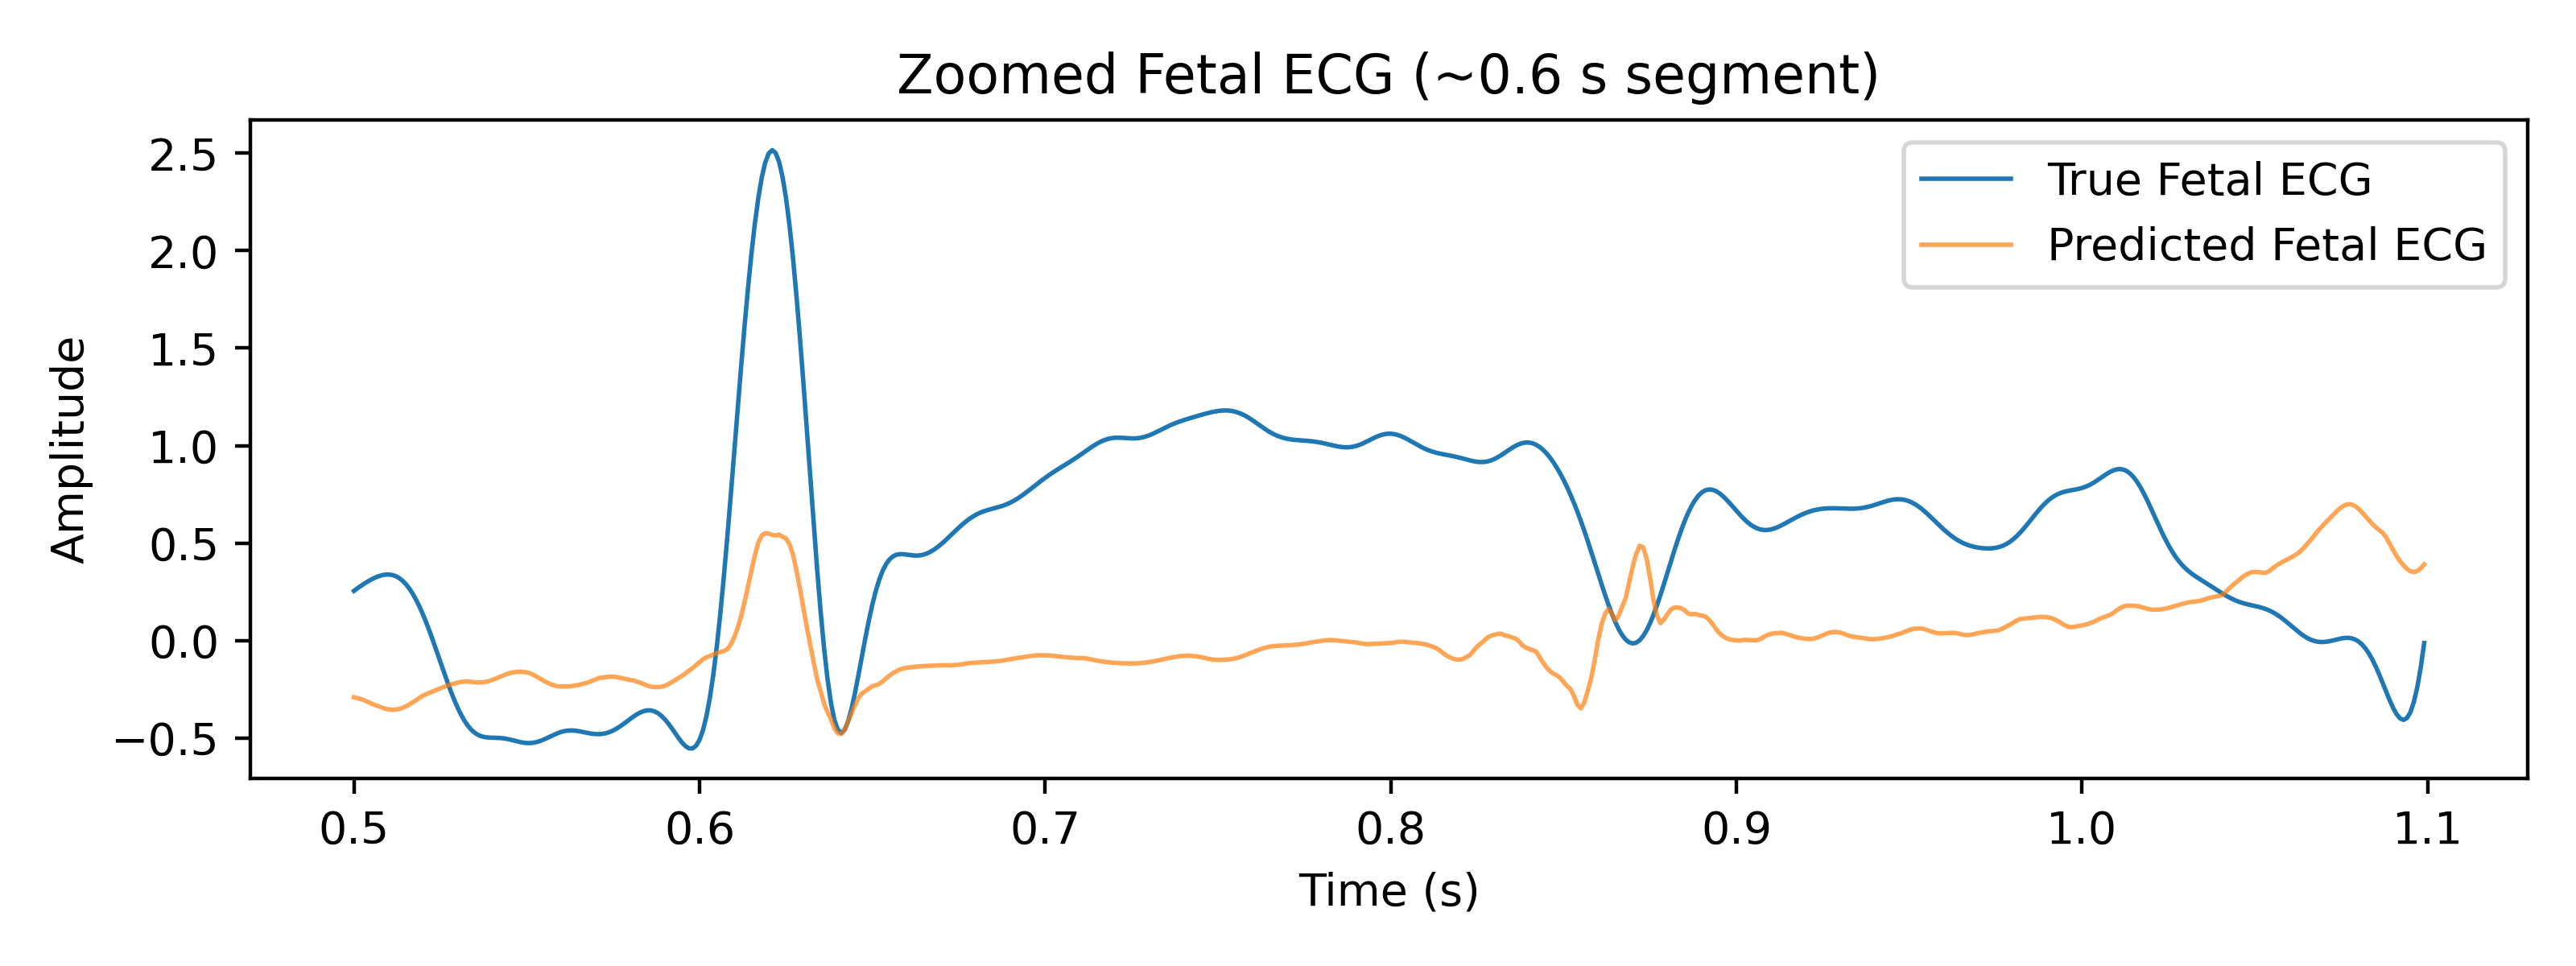

In [ ]:
from IPython.display import Image, display
import os

figures_dir = "figures"

if os.path.exists(figures_dir):
    image_files = [f for f in os.listdir(figures_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    image_files.sort()
    if image_files:
        for img_file in image_files:
            print(f"Displaying {img_file}:")
            display(Image(filename=os.path.join(figures_dir, img_file)))
    else:
        print("No image files found in the 'figures' directory.")
else:
    print(f"The directory '{figures_dir}' does not exist.")